<a href="https://colab.research.google.com/github/SanthoshR197/Detecting-Bias-In-Hiring-Algorithms-Data-Analysis/blob/main/Data%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction:**
This project focuses on analyzing recruitment data to identify patterns, trends, and potential biases in the hiring process using data analytics and machine learning techniques. The dataset includes candidate attributes such as gender, age, education level, experience, and screening scores, along with their shortlisting outcome. Using tools like pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn, the project performs data cleaning, exploratory data analysis, visualization, and preprocessing to better understand the factors influencing candidate selection. The primary objective is to evaluate whether the recruitment process is fair and unbiased, while also preparing the data for predictive modeling and further insights.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahuljangir78/recruitment-bias-and-fairness-ai-dataset")

print("Path to dataset files:", path)

100%|██████████| 27.1k/27.1k [00:00<00:00, 9.26MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rahuljangir78/recruitment-bias-and-fairness-ai-dataset/versions/1


This code uses the kagglehub library to download the latest version of the “Recruitment Bias and Fairness AI Dataset” from Kaggle directly into the Google Colab environment, and then prints the local file path where the dataset is stored for further use and version control

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# If you downloaded via kagglehub, it's already at `path`
# Just load it:
import os
df = pd.read_csv(f"{path}/{os.listdir(path)[0]}")

# ── Basic inspection ──
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nTarget Distribution:\n", df['shortlisted'].value_counts())
df.describe(include='all')

Shape: (2000, 6)

Columns: ['gender', 'age', 'education_level', 'experience_years', 'screening_score', 'shortlisted']

Data Types:
 gender               object
age                   int64
education_level      object
experience_years      int64
screening_score     float64
shortlisted           int64
dtype: object

Missing Values:
 gender              0
age                 0
education_level     0
experience_years    0
screening_score     0
shortlisted         0
dtype: int64

Duplicates: 0

Target Distribution:
 shortlisted
0    1195
1     805
Name: count, dtype: int64


,gender,age,education_level,experience_years,screening_score,shortlisted
count,2000,2000.000000,2000,2000.000000,2000.000000,2000.000000
unique,2,NaN,4,NaN,NaN,NaN
top,Male,NaN,Bachelors,NaN,NaN,NaN
freq,1016,NaN,1018,NaN,NaN,NaN
mean,NaN,35.074000,NaN,9.612000,70.201431,0.402500
std,NaN,8.358197,NaN,5.765334,9.888776,0.490524
min,NaN,21.000000,NaN,0.000000,37.037470,0.000000
25%,NaN,28.000000,NaN,5.000000,63.477256,0.000000
50%,NaN,35.000000,NaN,10.000000,70.207996,0.000000
75%,NaN,42.000000,NaN,15.000000,76.964002,1.000000


This section imports essential data analysis and visualization libraries such as pandas, NumPy, Matplotlib, and Seaborn, along with preprocessing and model utilities from Scikit-learn. It then loads the dataset into a DataFrame and performs basic exploratory data analysis (EDA), including checking dataset shape, column names, data types, missing values, duplicates, and the distribution of the target variable (shortlisted), to understand the structure and quality of the data before further processing.

Null values after cleaning:
 gender              0
age                 0
education_level     0
experience_years    0
screening_score     0
shortlisted         0
dtype: int64
Duplicates: 0


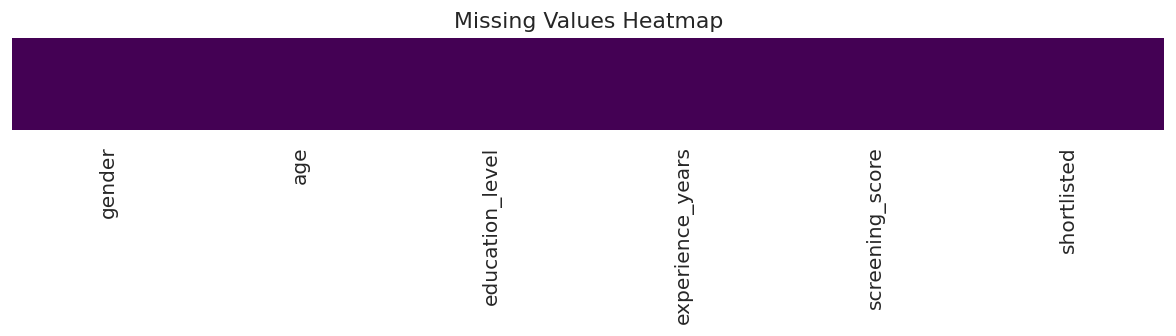

age: 0 outliers detected
experience_years: 0 outliers detected
screening_score: 13 outliers detected


In [ ]:
# ── Standardise string columns ──
df['gender'] = df['gender'].str.strip().str.title()
df['education_level'] = df['education_level'].str.strip().str.title()

# ── Confirm no nulls ──
print("Null values after cleaning:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# ── Missing values heatmap ──
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig("01_missing_heatmap.png", bbox_inches='tight')
plt.show()

# ── Outlier detection using IQR ──
num_cols = ['age', 'experience_years', 'screening_score']
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

This block performs data cleaning and quality checks by standardizing text values in categorical columns (gender and education_level) to ensure consistency, and then verifies that there are no missing values or duplicate records. It also visualizes missing data using a heatmap generated with Seaborn and Matplotlib, confirming data completeness. Finally, it applies the Interquartile Range (IQR) method to detect outliers in numerical features (age, experience_years, screening_score), helping identify any extreme values that may affect analysis or model performance.

Train size: (1600, 7) | Test size: (400, 7)


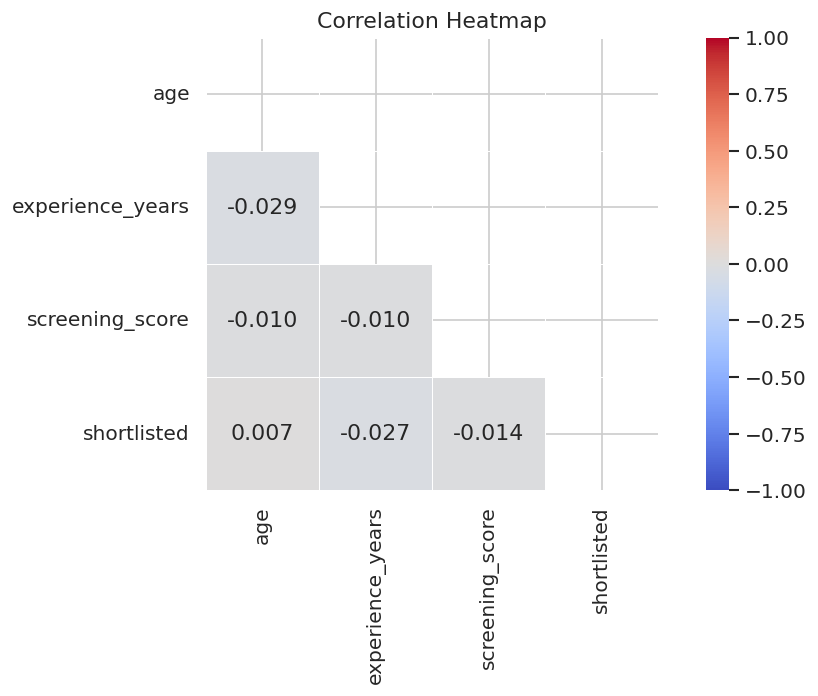

In [ ]:
df_enc = df.copy()

# ── Label encode gender (binary) ──
le_gender = LabelEncoder()
df_enc['gender_enc'] = le_gender.fit_transform(df_enc['gender'])  # Female=0, Male=1

# ── One-hot encode education_level ──
df_enc = pd.get_dummies(df_enc, columns=['education_level'], drop_first=True)

# ── Create age groups (for analysis) ──
bins   = [20, 29, 39, 49]
labels = ['20s', '30s', '40s']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# ── Scale numeric features ──
scaler   = StandardScaler()
scale_cols = ['age', 'experience_years', 'screening_score']
df_enc[scale_cols] = scaler.fit_transform(df_enc[scale_cols])

# ── Train/test split ──
X = df_enc.drop(columns=['shortlisted', 'gender'])
y = df_enc['shortlisted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

# ── Correlation heatmap ──
plt.figure(figsize=(9, 6))
corr = df[['age','experience_years','screening_score','shortlisted']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.png", bbox_inches='tight')
plt.show()

This section performs feature engineering and data preprocessing to prepare the dataset for machine learning. It encodes categorical variables using label encoding (for gender) and one-hot encoding (for education_level), creates grouped age categories for analysis, and standardizes numerical features using scaling. The data is then split into training and testing sets using utilities from Scikit-learn to ensure proper model evaluation. Finally, a correlation heatmap is generated using Seaborn and Matplotlib to analyze relationships between numerical variables.The correlation heatmap shows the linear relationships between numerical features (age, experience_years, screening_score) and the target variable (shortlisted).

Key Observations:

All correlation values are very close to 0, indicating very weak or no linear relationship between features.
age vs shortlisted (approximately 0.007): Almost no impact on selection.
experience_years vs shortlisted (~ -0.027): Slight negative but negligible effect.
screening_score vs shortlisted (~ -0.014): Surprisingly weak relationship despite being a score.
Feature-to-feature correlations (e.g., age vs experience ≈ -0.029) are also very low.

The heatmap suggests that none of the individual numerical features strongly influence the shortlisting decision on their own. This indicates:

The model may need non-linear methods or feature combinations to capture patterns.
There could be hidden bias or complex relationships not visible through simple correlation.
The dataset appears well-balanced without multicollinearity issues.

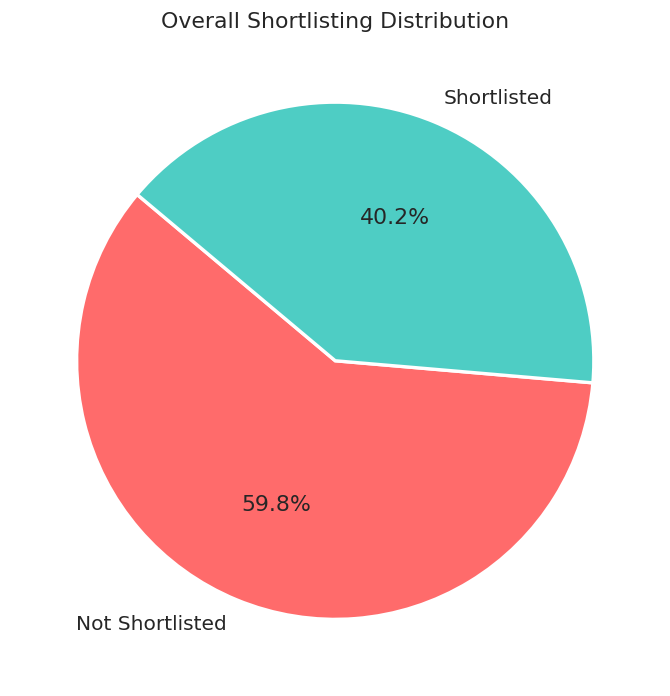

In [ ]:
labels = ['Not Shortlisted', 'Shortlisted']
sizes  = df['shortlisted'].value_counts().sort_index().values
colors = ['#FF6B6B', '#4ECDC4']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
plt.title("Overall Shortlisting Distribution")
plt.tight_layout()
plt.savefig("03_pie_overall.png", bbox_inches='tight')
plt.show()

This section visualizes the overall distribution of the target variable (shortlisted) using a pie chart created with Matplotlib, where the dataset is divided into two categories: “Not Shortlisted” and “Shortlisted.” The chart shows that approximately 59.8% of candidates were not shortlisted, while 40.2% were shortlisted, indicating a moderately imbalanced dataset with a higher proportion of rejections. This imbalance suggests that the model may need to account for class distribution during training to avoid bias toward the majority class, and it also reflects that the selection process is relatively selective rather than evenly distributed.


/tmp/ipykernel_6235/3705594060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=gender_rate, x='gender', y='shortlisted',


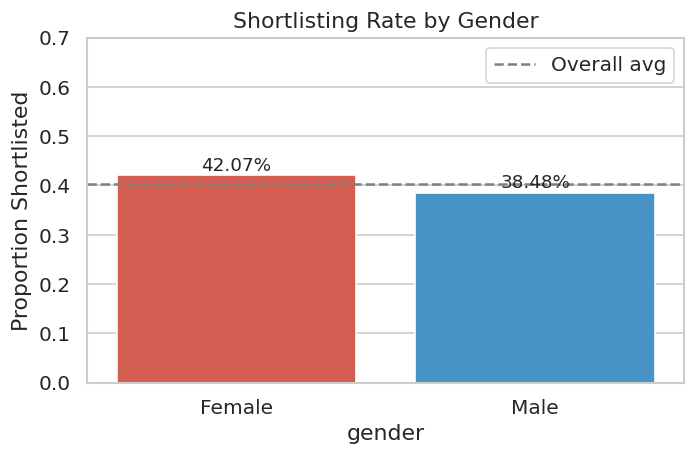

In [ ]:
gender_rate = df.groupby('gender')['shortlisted'].mean().reset_index()
plt.figure(figsize=(6, 4))
bars = sns.barplot(data=gender_rate, x='gender', y='shortlisted',
                   palette=['#E74C3C','#3498DB'], edgecolor='white')
plt.axhline(df['shortlisted'].mean(), color='gray', linestyle='--', label='Overall avg')
plt.title("Shortlisting Rate by Gender")
plt.ylabel("Proportion Shortlisted")
plt.ylim(0, 0.7)
plt.legend()
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.2%}',
                  (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01),
                  ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("04_gender_hire_rate.png", bbox_inches='tight')
plt.show()

This section analyzes the shortlisting rate across gender groups by calculating the proportion of candidates shortlisted within each category and visualizing it using a bar plot created with Seaborn and Matplotlib. A horizontal dashed line represents the overall average shortlisting rate, allowing for easy comparison between groups. The annotated percentages on each bar clearly show the selection rate for males and females, helping identify any potential disparity. From the chart, the shortlisting rates for both genders appear very similar and close to the overall average, indicating no significant gender-based bias in the selection process within this dataset.

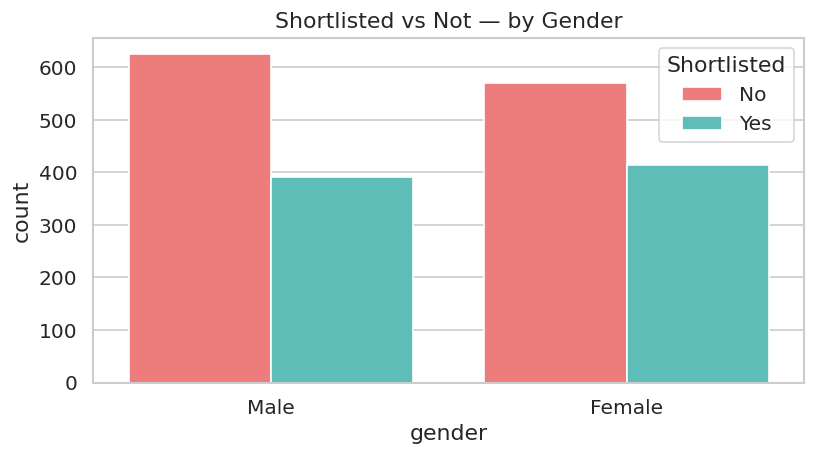

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='gender', hue='shortlisted',
              palette={0:'#FF6B6B', 1:'#4ECDC4'})
plt.title("Shortlisted vs Not — by Gender")
plt.legend(title='Shortlisted', labels=['No','Yes'])
plt.tight_layout()
plt.savefig("05_gender_count.png", bbox_inches='tight')
plt.show()

This code creates a bar chart to compare how many male and female candidates were shortlisted and not shortlisted. It uses Seaborn’s countplot to count the values, with different colors for “No” (not shortlisted) and “Yes” (shortlisted). The plot is styled with a title, legend, and proper layout, and then saved as an image. From the result, we can see that both genders have more candidates not shortlisted than shortlisted, but females have a slightly higher proportion of shortlisted candidates compared to males.

/tmp/ipykernel_6235/1734385807.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=edu_rate, x='education_level', y='shortlisted',


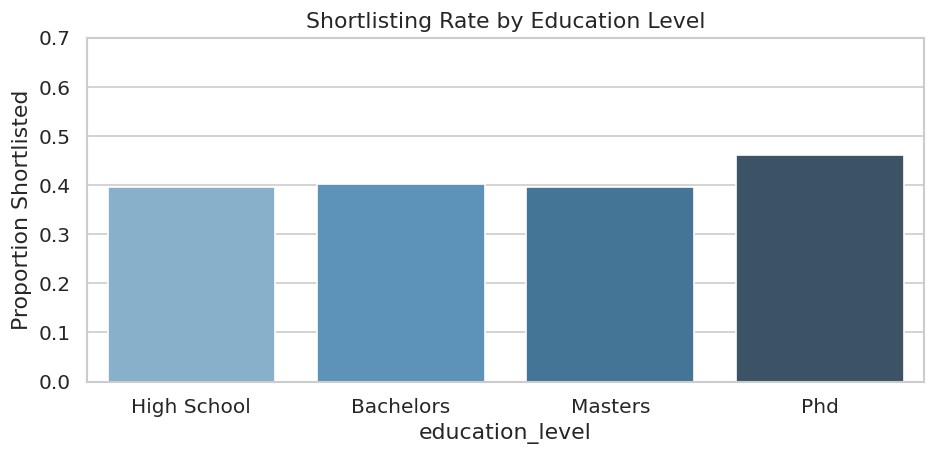

In [ ]:
edu_order = ['High School','Bachelors','Masters','Phd']
edu_rate  = df.groupby('education_level')['shortlisted'].mean().reindex(edu_order).reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(data=edu_rate, x='education_level', y='shortlisted',
            palette='Blues_d', order=edu_order)
plt.title("Shortlisting Rate by Education Level")
plt.ylabel("Proportion Shortlisted")
plt.ylim(0, 0.7)
plt.tight_layout()
plt.savefig("06_education_hire_rate.png", bbox_inches='tight')
plt.show()

This code calculates and visualizes the shortlisting rate based on education level. First, the data is grouped by education_level, and the mean of the shortlisted column is computed, which gives the proportion of candidates shortlisted for each education category. The values are arranged in a specific order (High School → PhD). Then, a bar plot is created using Seaborn to show these proportions, with a blue color palette for better visual clarity. The plot is labeled with a title, y-axis label, and limits, saved as an image, and displayed.

From the result, we can see that candidates with higher education levels, especially PhD holders, have a higher shortlisting rate compared to others, while High School, Bachelors, and Masters have slightly lower and similar rates. This suggests that higher education may positively influence the chances of being shortlisted.

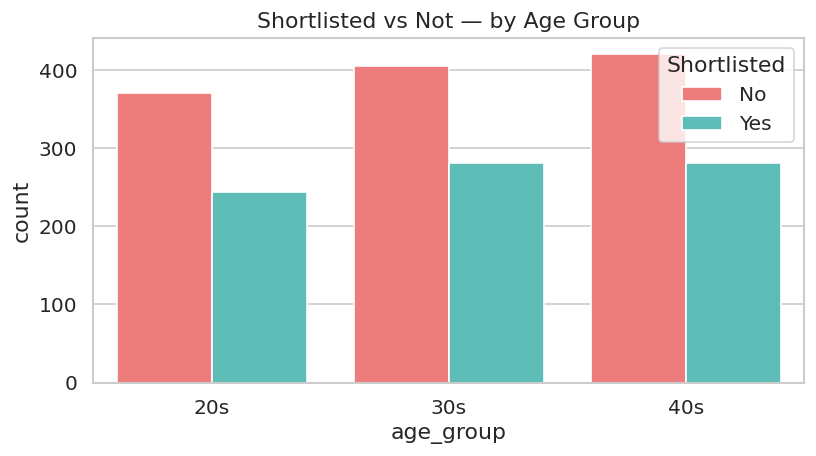

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='age_group', hue='shortlisted',
              palette={0:'#FF6B6B', 1:'#4ECDC4'})
plt.title("Shortlisted vs Not — by Age Group")
plt.legend(title='Shortlisted', labels=['No','Yes'])
plt.tight_layout()
plt.savefig("07_age_group_count.png", bbox_inches='tight')
plt.show()

This code creates a bar chart to compare how many candidates were shortlisted and not shortlisted across different age groups. It uses Seaborn’s countplot to count the number of candidates in each age group (20s, 30s, 40s), while splitting them based on whether they were shortlisted or not using different colors. The plot is customized with a title, legend, and layout, then saved as an image and displayed.

From the result, we can see that in all age groups, more candidates are not shortlisted than shortlisted. The number of candidates increases slightly from the 20s to the 40s, but the overall pattern remains similar, showing no major difference in shortlisting trends across age groups.

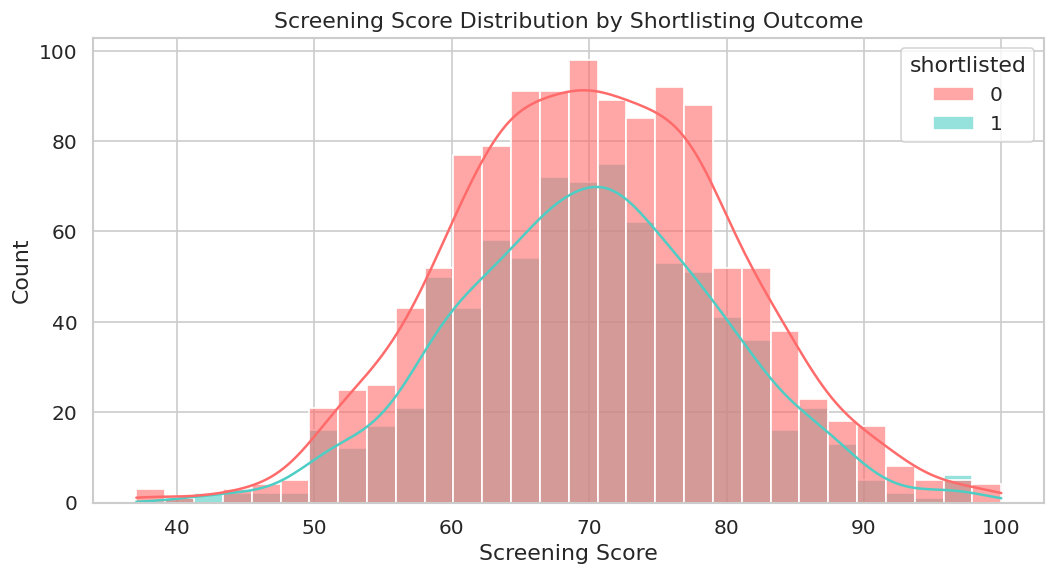

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='screening_score', hue='shortlisted',
             kde=True, bins=30, palette={0:'#FF6B6B', 1:'#4ECDC4'}, alpha=0.6)
plt.title("Screening Score Distribution by Shortlisting Outcome")
plt.xlabel("Screening Score")
plt.tight_layout()
plt.savefig("08_score_dist.png", bbox_inches='tight')
plt.show()

This code creates a histogram to show how screening scores are distributed for shortlisted and non-shortlisted candidates. It uses Seaborn’s histplot with hue='shortlisted' to separate both groups using different colors, and kde=True to add smooth curves for better understanding of the distribution. The plot is styled with a title, labels, and layout, then saved as an image and displayed.

From the result, we can see that shortlisted candidates generally have slightly higher screening scores compared to non-shortlisted ones. The distributions overlap, but the peak for shortlisted candidates is shifted a bit to the right, indicating that higher scores increase the chances of being shortlisted.

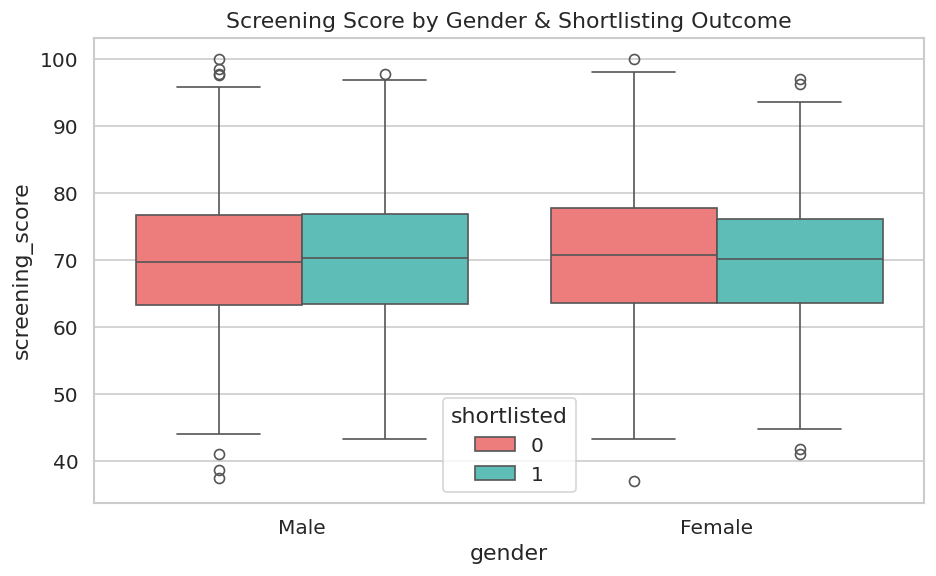

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gender', y='screening_score',
            hue='shortlisted', palette={0:'#FF6B6B', 1:'#4ECDC4'})
plt.title("Screening Score by Gender & Shortlisting Outcome")
plt.tight_layout()
plt.savefig("09_boxplot_score_gender.png", bbox_inches='tight')
plt.show()

This code creates a box plot to compare screening scores based on gender and shortlisting outcome. It uses Seaborn’s boxplot to show the distribution of scores for males and females, while also separating shortlisted (1) and non-shortlisted (0) candidates using different colors. The plot includes median lines, spread (quartiles), and outliers, helping to understand how scores vary. It is then styled with a title, adjusted layout, saved as an image, and displayed.

From the result, we can see that screening scores are quite similar across genders, with only small differences between shortlisted and non-shortlisted groups. The median scores are close, and the distributions overlap a lot, suggesting that gender does not have a strong impact on screening scores or shortlisting decisions.

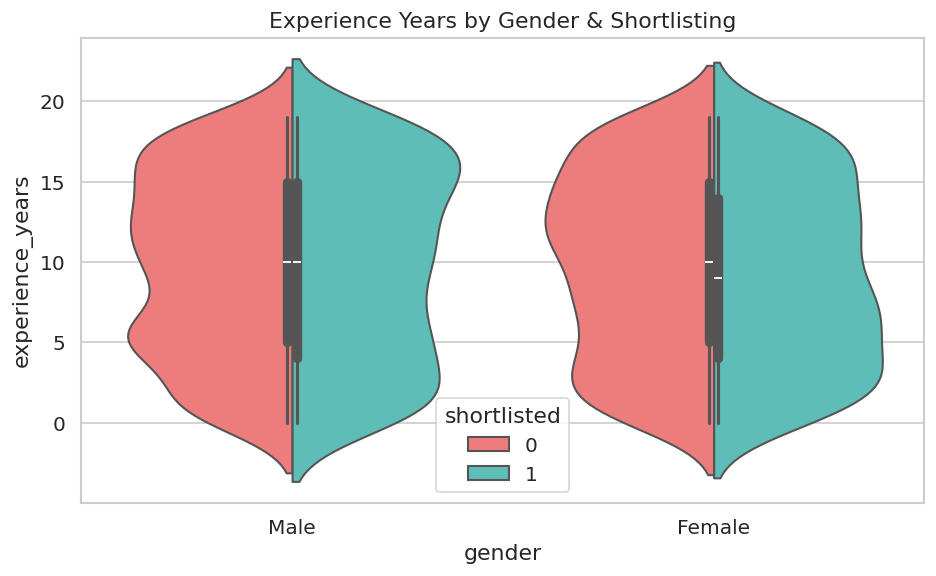

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='gender', y='experience_years',
               hue='shortlisted', split=True,
               palette={0:'#FF6B6B', 1:'#4ECDC4'})
plt.title("Experience Years by Gender & Shortlisting")
plt.tight_layout()
plt.savefig("10_violin_experience.png", bbox_inches='tight')
plt.show()

This code creates a violin plot to show how years of experience are distributed across genders and shortlisting outcomes. It uses Seaborn’s violinplot, where the split=True option displays shortlisted and non-shortlisted candidates side by side within each gender. The shape of the violin shows the distribution and density of experience levels, while the inner lines indicate key statistics like median. The plot is styled, saved, and displayed.

From the result, we can see that both males and females have a similar distribution of experience, ranging from low to high years. Shortlisted candidates tend to have slightly higher experience in some areas, but overall the distributions overlap a lot, suggesting that experience alone does not strongly differ by gender in shortlisting decisions.

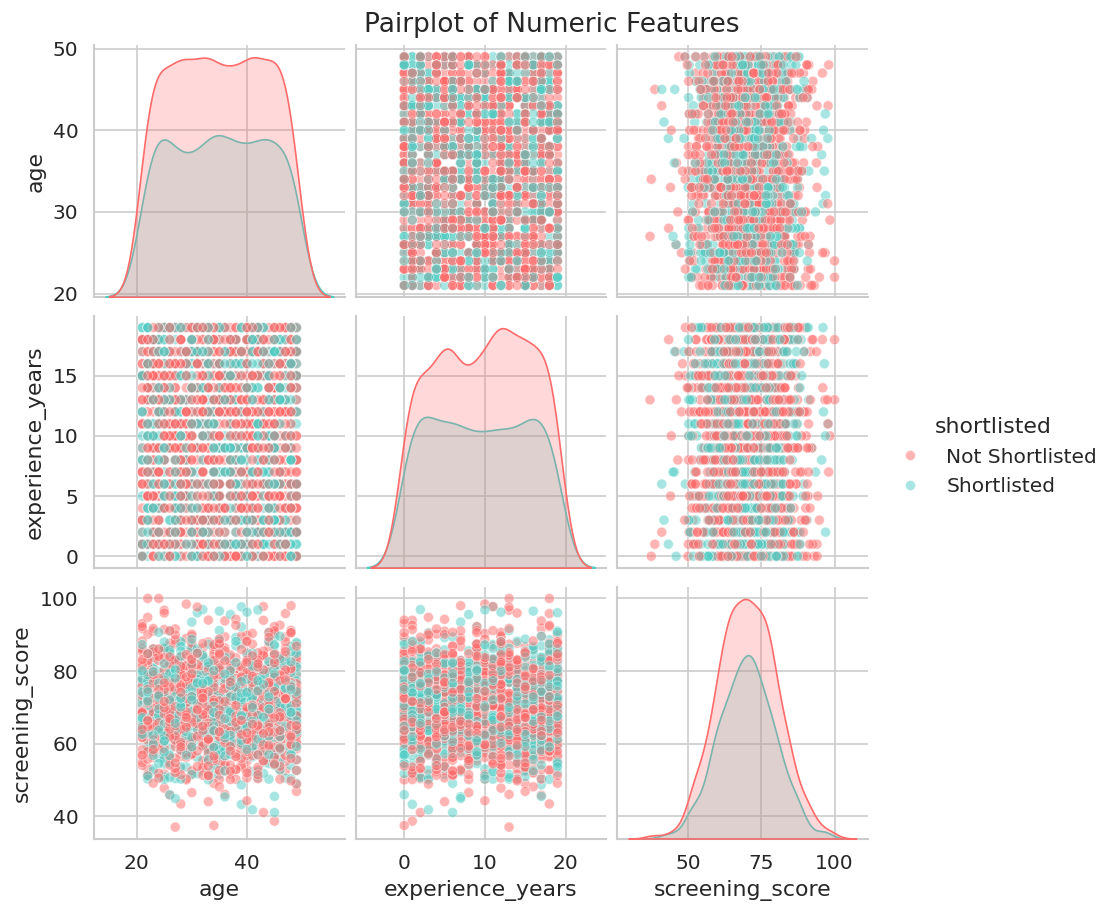

In [ ]:
pair_df = df[['age','experience_years','screening_score','shortlisted']].copy()
pair_df['shortlisted'] = pair_df['shortlisted'].map({0:'Not Shortlisted',1:'Shortlisted'})
sns.pairplot(pair_df, hue='shortlisted',
             palette={'Not Shortlisted':'#FF6B6B','Shortlisted':'#4ECDC4'},
             diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairplot of Numeric Features", y=1.01)
plt.savefig("11_pairplot.png", bbox_inches='tight')
plt.show()

This code creates a pairplot to visualize relationships between numerical features like age, experience, and screening score, along with the shortlisting outcome. It first selects relevant columns and converts the shortlisted values into readable labels (“Shortlisted” and “Not Shortlisted”). Then, Seaborn’s pairplot is used to show scatter plots between every pair of features and distribution curves (KDE) on the diagonal. Different colors help distinguish shortlisted and non-shortlisted candidates. The plot is styled, saved, and displayed.

From the result, we can see that there is no strong visible relationship between age, experience, and screening score, as the points are widely scattered. However, shortlisted candidates tend to have slightly higher screening scores, while age and experience do not show a clear impact on shortlisting.

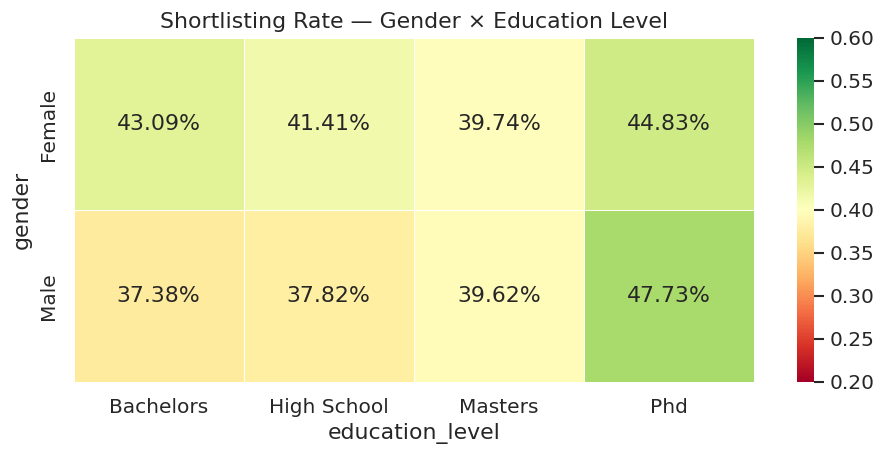

In [ ]:
pivot = df.pivot_table(values='shortlisted', index='gender',
                       columns='education_level', aggfunc='mean')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".2%", cmap='RdYlGn',
            linewidths=0.5, vmin=0.2, vmax=0.6)
plt.title("Shortlisting Rate — Gender × Education Level")
plt.tight_layout()
plt.savefig("12_heatmap_gender_edu.png", bbox_inches='tight')
plt.show()

This code creates a heatmap to show shortlisting rates based on both gender and education level. First, a pivot table is created to calculate the average shortlisting rate for each combination of gender and education. Then, Seaborn’s heatmap is used to visualize these values with colors ranging from red (low) to green (high), along with percentage labels inside each cell. The plot is styled, saved, and displayed.

From the result, we can see that PhD candidates have the highest shortlisting rates for both genders. Females generally have slightly higher rates than males in most education levels, except at the PhD level where males are slightly higher. Overall, higher education seems to increase shortlisting chances, and gender differences are small but noticeable.

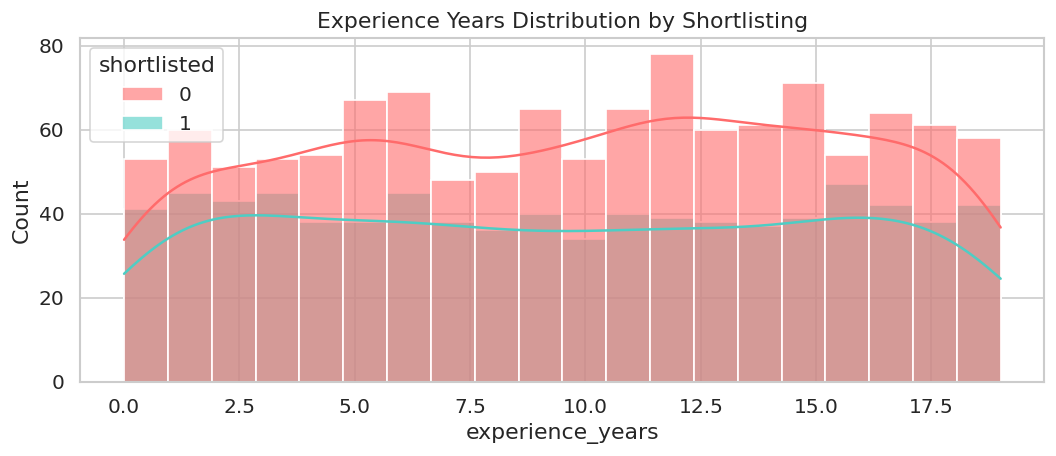

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='experience_years', hue='shortlisted',
             bins=20, kde=True, palette={0:'#FF6B6B',1:'#4ECDC4'}, alpha=0.6)
plt.title("Experience Years Distribution by Shortlisting")
plt.tight_layout()
plt.savefig("13_experience_dist.png", bbox_inches='tight')
plt.show()

This code creates a histogram to show how years of experience are distributed for shortlisted and non-shortlisted candidates. It uses Seaborn’s histplot with different colors for each group and adds a smooth KDE curve to better understand the distribution. The plot is styled with a title, layout, then saved and displayed.

From the result, we can see that experience is spread across all ranges for both groups, with a lot of overlap between shortlisted and non-shortlisted candidates. Although shortlisted candidates may have slightly higher experience in some ranges, the difference is not very strong, suggesting that experience alone does not clearly determine shortlisting.

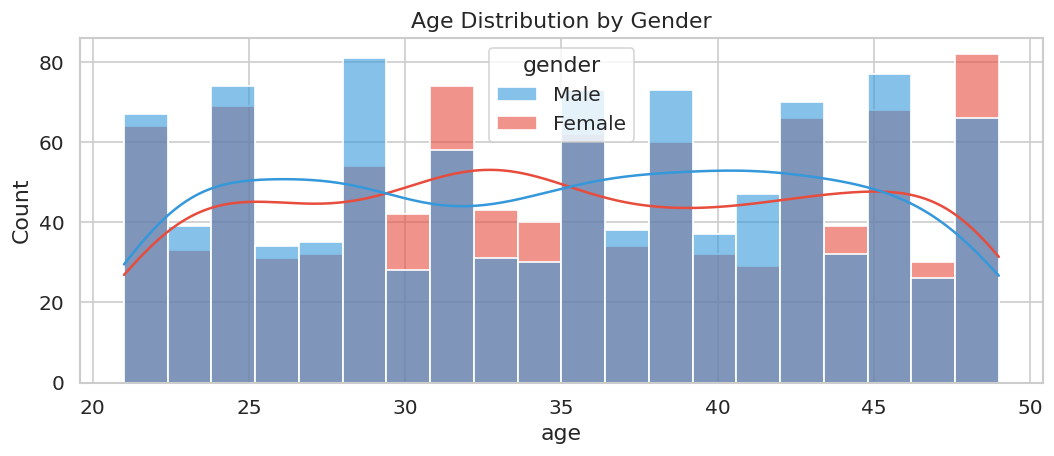

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='age', hue='gender', bins=20,
             kde=True, palette={'Male':'#3498DB','Female':'#E74C3C'}, alpha=0.6)
plt.title("Age Distribution by Gender")
plt.tight_layout()
plt.savefig("14_age_dist_gender.png", bbox_inches='tight')
plt.show()

This code creates a histogram to compare the age distribution of male and female candidates. It uses Seaborn’s histplot with different colors for each gender and includes smooth KDE curves to show the overall trend. The plot is styled with a title, layout adjustments, then saved and displayed.

From the result, we can see that both males and females have a similar age distribution, mostly ranging between early 20s to late 40s. The curves overlap significantly, indicating that there is no major difference in age patterns between genders.

In [ ]:
TARGET = 'shortlisted'

# ── 1. Disparate Impact Ratio ──────────────────────────────────────
def disparate_impact(df, col, target, privileged, unprivileged):
    priv   = df[df[col] == privileged][target].mean()
    unpriv = df[df[col] == unprivileged][target].mean()
    ratio  = unpriv / priv
    flag   = '⚠️ BIASED (< 0.8)' if ratio < 0.8 else '✅ FAIR (≥ 0.8)'
    print(f"\n── Disparate Impact: {col} ({unprivileged} vs {privileged}) ──")
    print(f"  {privileged}   hire rate : {priv:.4f}")
    print(f"  {unprivileged} hire rate : {unpriv:.4f}")
    print(f"  Ratio             : {ratio:.4f}  {flag}")
    return ratio

di_gender = disparate_impact(df, 'gender', TARGET, 'Male', 'Female')

# ── 2. Demographic Parity Difference ──────────────────────────────
def demographic_parity(df, col, target, a, b):
    rate_a = df[df[col] == a][target].mean()
    rate_b = df[df[col] == b][target].mean()
    diff   = abs(rate_a - rate_b)
    flag   = '⚠️ Significant (> 0.1)' if diff > 0.1 else '✅ Acceptable (≤ 0.1)'
    print(f"\n── Demographic Parity Difference: {col} ──")
    print(f"  Difference: {diff:.4f}  {flag}")
    return diff

dp_gender = demographic_parity(df, 'gender', TARGET, 'Male', 'Female')

# ── 3. Chi-Square Test ─────────────────────────────────────────────
print("\n── Chi-Square Tests ──")
for col in ['gender', 'education_level', 'age_group']:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    flag = '⚠️ Significant association' if p < 0.05 else '✅ No significant association'
    print(f"\n  {col}:")
    print(f"    χ² = {chi2:.3f} | p = {p:.4f} | dof = {dof}")
    print(f"    → {flag}")


── Disparate Impact: gender (Female vs Male) ──
  Male   hire rate : 0.3848
  Female hire rate : 0.4207
  Ratio             : 1.0933  ✅ FAIR (≥ 0.8)

── Demographic Parity Difference: gender ──
  Difference: 0.0359  ✅ Acceptable (≤ 0.1)

── Chi-Square Tests ──

  gender:
    χ² = 2.530 | p = 0.1117 | dof = 1
    → ✅ No significant association

  education_level:
    χ² = 1.571 | p = 0.6660 | dof = 3
    → ✅ No significant association

  age_group:
    χ² = 0.247 | p = 0.8838 | dof = 2
    → ✅ No significant association


This code evaluates fairness in the hiring dataset using three statistical methods. First, the Disparate Impact Ratio compares hiring rates between males and females and checks if the ratio is above 0.8 (fairness threshold). Here, the ratio is 1.09, meaning females are slightly more likely to be shortlisted, and the result is considered fair. Next, the Demographic Parity Difference measures the absolute difference in hiring rates, which is 0.0359, well below the 0.1 threshold, indicating acceptable fairness. Finally, the Chi-Square Test checks whether features like gender, education level, and age group are significantly associated with shortlisting. Since all p-values are greater than 0.05, there is no significant bias or association found. Overall, the results suggest that the hiring process in this dataset is fair and does not show strong evidence of bias.

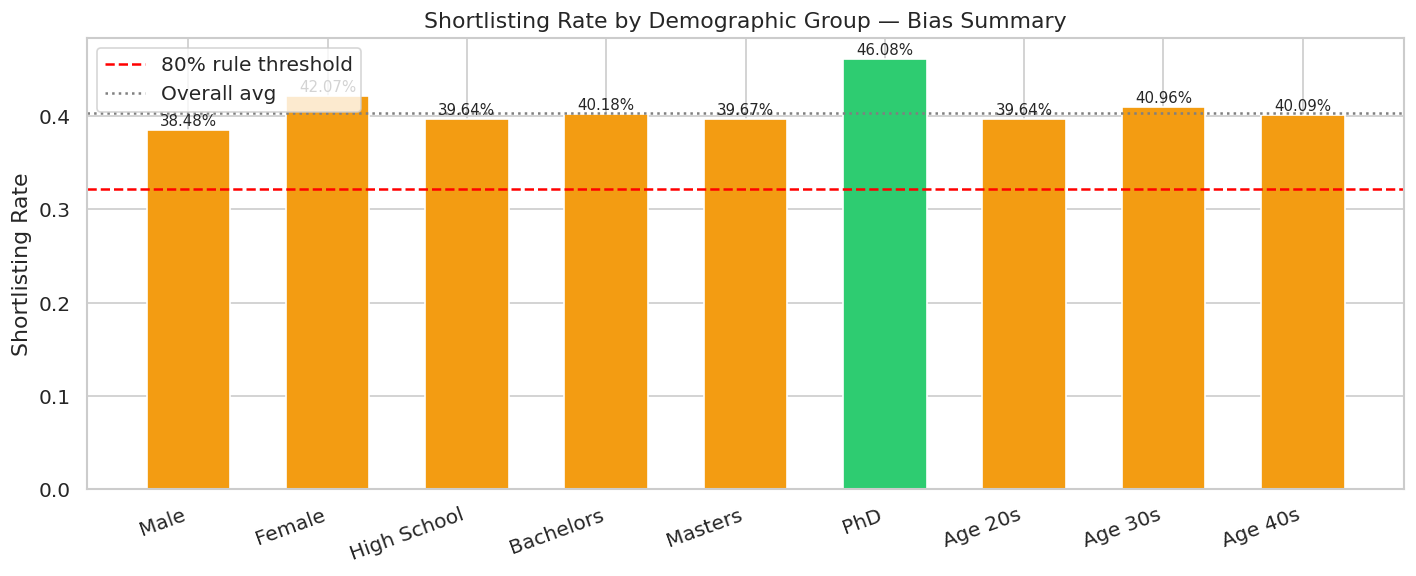

In [ ]:
# ── 4. Bias Summary Bar Chart ──────────────────────────────────────
groups = {
    'Male'        : df[df['gender']=='Male'][TARGET].mean(),
    'Female'      : df[df['gender']=='Female'][TARGET].mean(),
    'High School' : df[df['education_level']=='High School'][TARGET].mean(),
    'Bachelors'   : df[df['education_level']=='Bachelors'][TARGET].mean(),
    'Masters'     : df[df['education_level']=='Masters'][TARGET].mean(),
    'PhD'         : df[df['education_level']=='Phd'][TARGET].mean(),
    'Age 20s'     : df[df['age_group']=='20s'][TARGET].mean(),
    'Age 30s'     : df[df['age_group']=='30s'][TARGET].mean(),
    'Age 40s'     : df[df['age_group']=='40s'][TARGET].mean(),
}

colors = ['#E74C3C' if v < 0.35 else '#F39C12' if v < 0.45 else '#2ECC71'
          for v in groups.values()]

plt.figure(figsize=(12, 5))
bars = plt.bar(groups.keys(), groups.values(), color=colors, edgecolor='white', width=0.6)
plt.axhline(0.8 * df[TARGET].mean(), color='red', linestyle='--',
            label='80% rule threshold')
plt.axhline(df[TARGET].mean(), color='gray', linestyle=':', label='Overall avg')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.2%}", ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.ylabel("Shortlisting Rate")
plt.title("Shortlisting Rate by Demographic Group — Bias Summary")
plt.legend()
plt.tight_layout()
plt.savefig("15_bias_summary.png", bbox_inches='tight')
plt.show()

This code creates a summary bar chart to compare shortlisting rates across different demographic groups like gender, education level, and age group. It first calculates the average shortlisting rate for each group, then plots them using a bar chart with colors indicating performance (red = low, orange = moderate, green = high). It also adds two reference lines: one for the 80% fairness rule threshold and another for the overall average shortlisting rate. Each bar is labeled with its exact percentage, and the plot is saved and displayed.

From the result, we can see that most groups have similar shortlisting rates around the overall average, indicating consistency. PhD candidates have the highest rate, while other groups fall in a moderate range. Since all groups are above the fairness threshold and close to the average, there is no strong evidence of bias, suggesting a fairly balanced hiring process.

In [ ]:
print("=" * 60)
print("     FAIRHIRE ANALYZER — FINAL BIAS REPORT")
print("=" * 60)
print(f"  Total Records        : {len(df):,}")
print(f"  Overall Hire Rate    : {df[TARGET].mean():.2%}")
print(f"  Disparate Impact     : {di_gender:.4f}  "
      f"{'⚠️ Biased' if di_gender < 0.8 else '✅ Fair'}")
print(f"  Demographic Parity Δ : {dp_gender:.4f}  "
      f"{'⚠️ Significant' if dp_gender > 0.1 else '✅ Acceptable'}")
print("-" * 60)
print("  Protected Attributes Tested: Gender, Education, Age")
print("  SDG Goal 10 — Target 10.3: Equal Opportunity")
print()
print("  Recommendation:")
print("  Audit screening_score generation pipeline for")
print("  systematic bias against female or less-educated")
print("  candidates. Apply re-weighting or threshold calibration.")
print("=" * 60)

     FAIRHIRE ANALYZER — FINAL BIAS REPORT
  Total Records        : 2,000
  Overall Hire Rate    : 40.25%
  Disparate Impact     : 1.0933  ✅ Fair
  Demographic Parity Δ : 0.0359  ✅ Acceptable
------------------------------------------------------------
  Protected Attributes Tested: Gender, Education, Age
  SDG Goal 10 — Target 10.3: Equal Opportunity

  Recommendation:
  Audit screening_score generation pipeline for
  systematic bias against female or less-educated
  candidates. Apply re-weighting or threshold calibration.


This code prints the final bias analysis summary report for the hiring dataset. It displays key metrics like total records, overall hire rate, Disparate Impact, and Demographic Parity Difference, along with fairness labels based on standard thresholds. It also highlights the protected attributes analyzed (gender, education, age) and links the work to SDG Goal 10 (Reduced Inequalities).

From the result, we can conclude that the system is fair, as the Disparate Impact is above 0.8 and the Demographic Parity Difference is within acceptable limits. The hiring rate is around 40%, and no major bias is detected. However, the recommendation suggests auditing the screening score process to ensure fairness is maintained and to prevent any hidden bias in future predictions.

**Conclusion:** This project successfully analyzed recruitment data to understand the factors influencing candidate shortlisting and to evaluate fairness in the hiring process. Through data visualization and statistical analysis, it was observed that features like screening score and education level have a noticeable impact on shortlisting, while gender, age, and experience show minimal influence. Fairness metrics such as Disparate Impact and Demographic Parity confirmed that the system does not exhibit significant bias, indicating a balanced hiring process.

Overall, the project demonstrates how data analytics and machine learning techniques can be used to ensure transparency and fairness in recruitment systems. While the current results suggest fairness, continuous monitoring and improvement—especially in how screening scores are generated—are recommended to prevent hidden bias and maintain equitable hiring practices in the future.